In [77]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [78]:
def get_contours(image_path):
    # Загрузка изображения
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Инвертируем изображение (пунктирные линии должны быть белыми)
    _, binary = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY_INV)

    # Применяем размытие, чтобы убрать шум
    blurred = cv2.GaussianBlur(binary, (5, 5), 0)

    # Используем морфологию для выделения прямоугольных структур
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    processed = cv2.morphologyEx(blurred, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Поиск контуров
    contours, _ = cv2.findContours(processed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=lambda x: x[0][0][1])
    contours = sorted(contours, key=lambda x: x[0][0][0])
    contours = sorted(contours, key=lambda c: (cv2.boundingRect(c)[1], cv2.boundingRect(c)[0]))

    # Копия изображения для отображения результатов
    output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Фильтруем и выделяем только прямоугольные блоки
    contours_valid = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        # Условие для фильтрации блоков по размеру
        if 100 < w < 150 and 100 < h < 200:  # Подстраивайте размеры под бланк
            contours_valid.append(contour)
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    return contours_valid, output

In [35]:
image_ref_pics = cv2.imread("C:/Users/zamko/Documents/mom_project/repo/data/ref_pics/ref_pics_raw.png")

In [36]:
contours_valid, output = get_contours("C:/Users/zamko/Documents/mom_project/repo/data/ref_pics/ref_pics_raw.png")

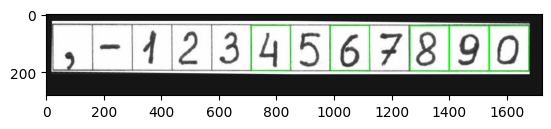

In [37]:
plt.imshow(output)
plt.show()


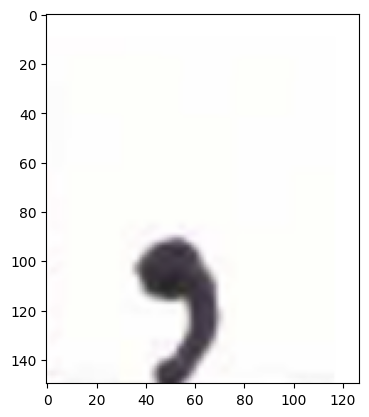

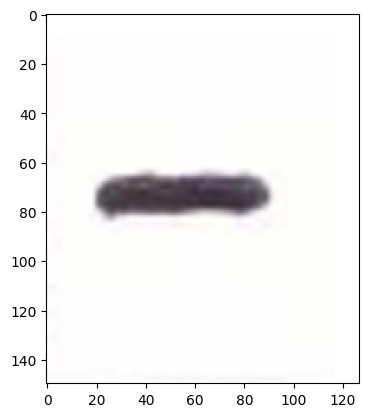

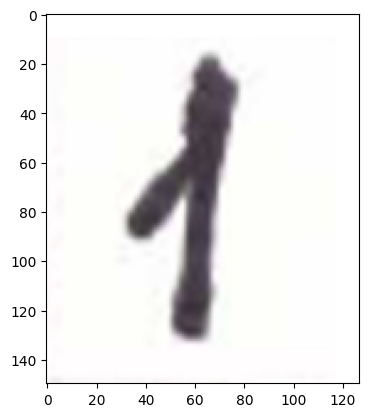

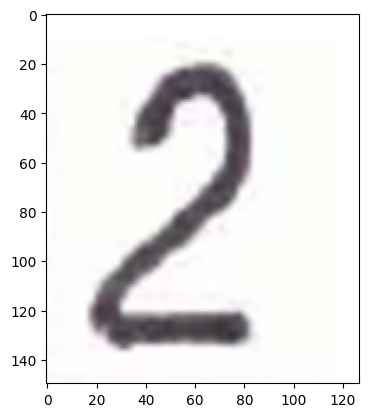

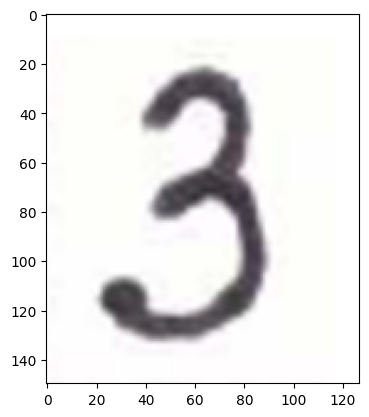

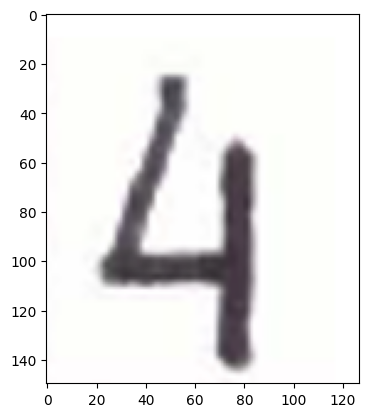

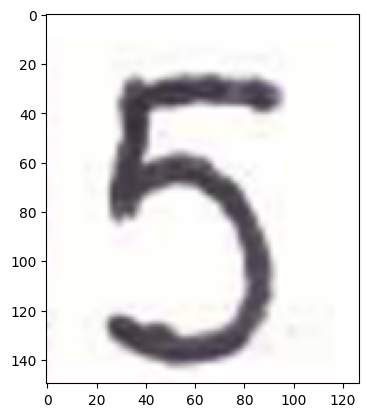

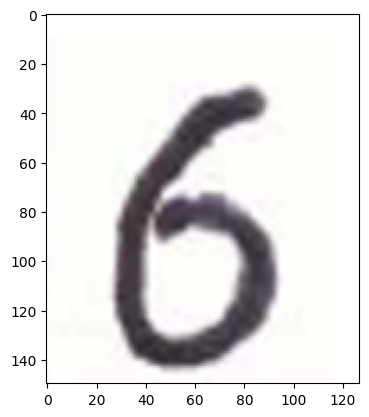

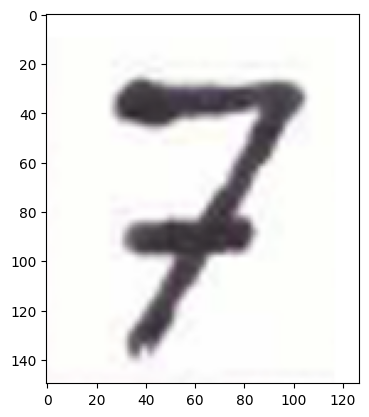

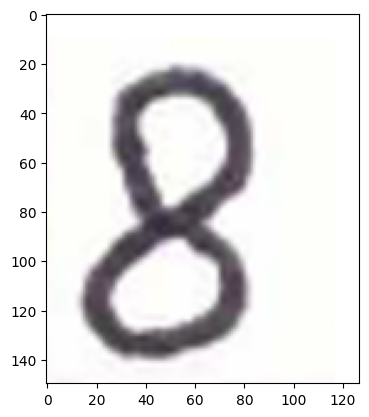

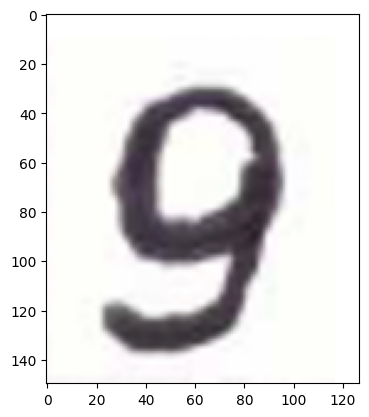

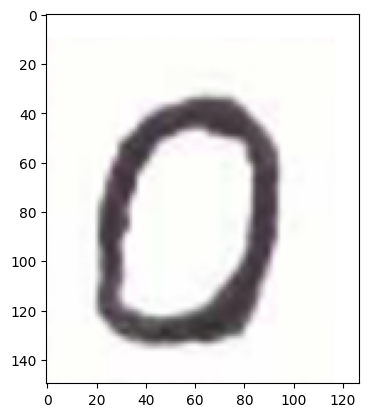

In [86]:
pics_dict = {}
pics_dict[1] = {'name':'comma', 'pic':None}
pics_dict[2] = {'name':'minus', 'pic':None}
pics_dict[3] = {'name':'one', 'pic':None}
pics_dict[4] = {'name':'two', 'pic':None}
pics_dict[5] = {'name':'three', 'pic':None}
pics_dict[6] = {'name':'four', 'pic':None}
pics_dict[7] = {'name':'five', 'pic':None}
pics_dict[8] = {'name':'six', 'pic':None}
pics_dict[9] = {'name':'seven', 'pic':None}
pics_dict[10] = {'name':'eight', 'pic':None}
pics_dict[11] = {'name':'nine', 'pic':None}
pics_dict[12] = {'name':'zero', 'pic':None}

for i in range(12):
    x = 29
    y = 40
    w = 127
    h = 150
    pad = 138*i
    pic = image_ref_pics[y:y+h, x + pad:x+w + pad]
    # make upper part of the pic white
    pic[:10, :] = 255
    pic[:, pic.shape[1]-10:] = 255
    pics_dict[i+1]['pic'] = pic
    plt.imshow(pic)
    plt.show()



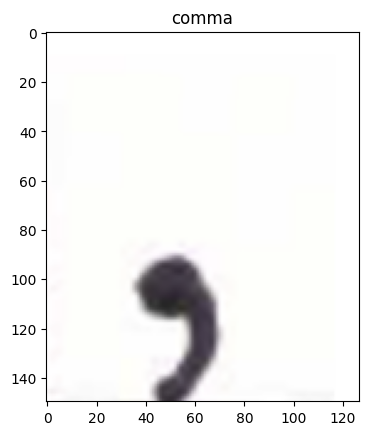

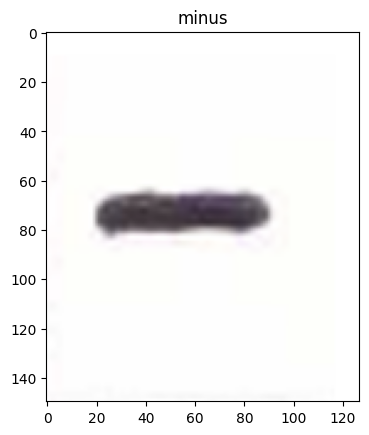

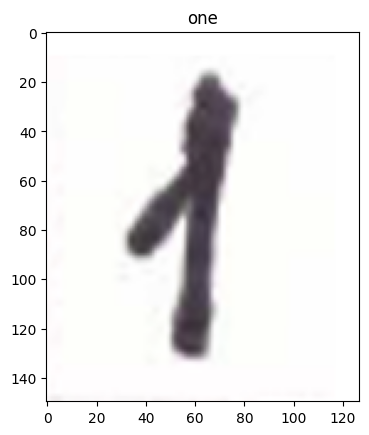

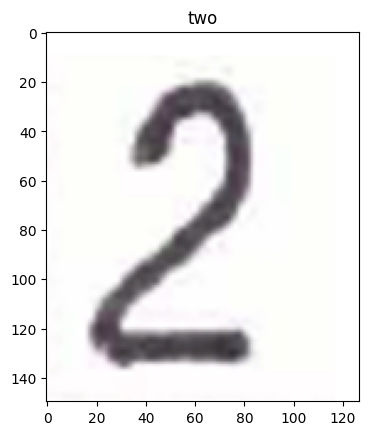

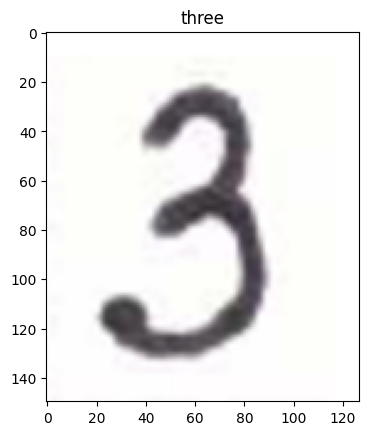

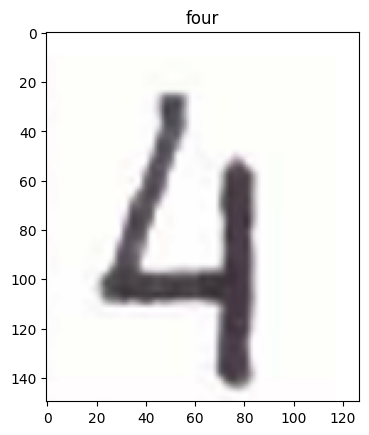

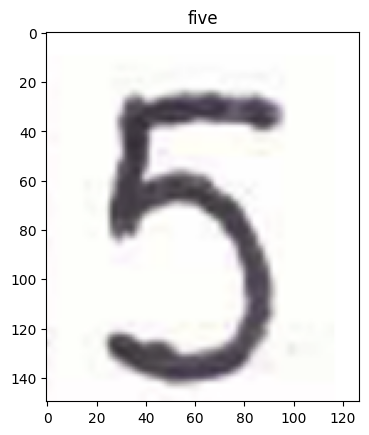

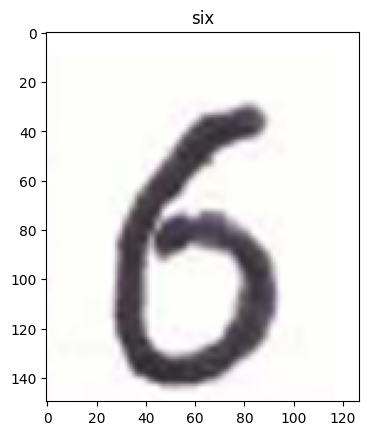

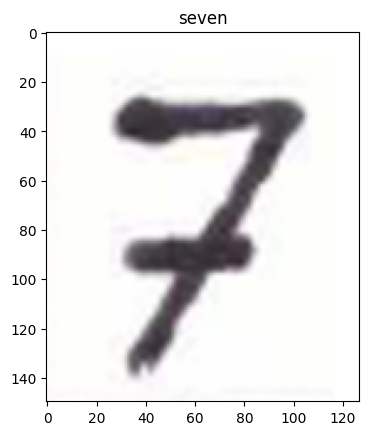

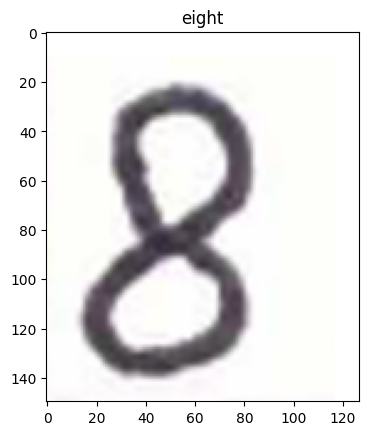

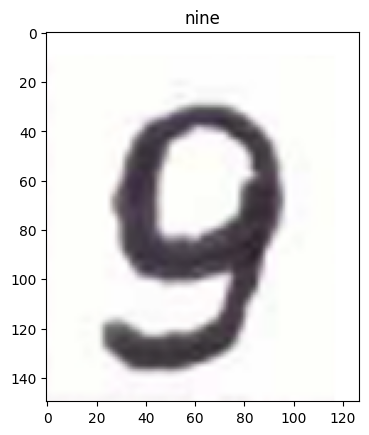

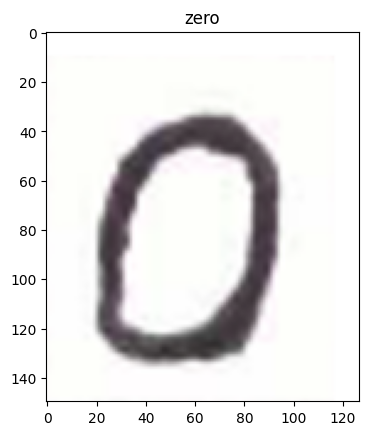

In [92]:
for i in pics_dict.keys():
    plt.imshow(pics_dict[i]['pic'])
    plt.title(pics_dict[i]['name'])
    plt.show()
    cv2.imwrite(f"C:/Users/zamko/Documents/mom_project/repo/data/ref_pics/{pics_dict[i]['name']}.png", pics_dict[i]['pic'])
